In [2]:
import numpy as np
from itertools import product
from collections import defaultdict
import numpy as np
from scipy.ndimage import gaussian_filter
from scipy.stats import norm


grid = np.array([
    [1, 0, 1, 1, 0],
    [0, 1, 1, 0, 1],
    [1, 1, 0, 0, 1],
    [0, 0, 1, 1, 0],
    [1, 0, 0, 1, 1],
])

print(grid)

[[1 0 1 1 0]
 [0 1 1 0 1]
 [1 1 0 0 1]
 [0 0 1 1 0]
 [1 0 0 1 1]]


In [2]:

def build_table(grid):
    # counts[(L, R)] = [n0, n1]  -> how often centre was 0 / 1 for that pattern
    counts = {pattern: [0, 0] for pattern in product([0, 1], repeat=2)}
    rows, cols = grid.shape

    # horizontal triples: L C R = grid[r, c-1], grid[r, c], grid[r, c+1]
    for r in range(rows):
        for c in range(1, cols - 1):
            L, C, R = grid[r, c-1], grid[r, c], grid[r, c+1]
            counts[(L, R)][C] += 1

    # vertical triples: L C R = grid[r-1, c], grid[r, c], grid[r+1, c]
    for c in range(cols):
        for r in range(1, rows - 1):
            L, C, R = grid[r-1, c], grid[r, c], grid[r+1, c]
            counts[(L, R)][C] += 1

    return counts

def print_table(counts):
    print(" L  R | count(C=0) | count(C=1) | P(C=1)")
    print("------+------------+------------+-------")
    for (L, R), (n0, n1) in counts.items():
        total = n0 + n1
        p = n1 / total if total > 0 else float("nan")
        print(f" {L}  {R} | {n0:^10} | {n1:^10} | {p:.3f}")

counts = build_table(grid)
print_table(counts)

 L  R | count(C=0) | count(C=1) | P(C=1)
------+------------+------------+-------
 0  0 |     0      |     2      | 1.000
 0  1 |     4      |     7      | 0.636
 1  0 |     4      |     7      | 0.636
 1  1 |     6      |     0      | 0.000


In [3]:
import numpy as np

rng = np.random.default_rng(0)          # seed -> same set every run
grids = rng.integers(0, 2, size=(100000, 3, 3))   

print(grids.shape)      

print(grids[0])         


(100000, 3, 3)
[[1 1 1]
 [0 0 0]
 [0 0 0]]


## make prob table with distinct patterns 

In [ ]:


def neighbours_and_centre(g):
    flat = g.flatten()               # index 4 is the middle
    centre = int(flat[4])
    neigh = tuple(int(x) for i, x in enumerate(flat) if i != 4)  # 8 outer cells
    return neigh, centre

def build_table(grids):
    counts = defaultdict(lambda: [0, 0])   # neighbours -> [n0, n1]
    for g in grids:
        neigh, centre = neighbours_and_centre(g)
        counts[neigh][centre] += 1
    return counts

table = build_table(grids)
print(f"{len(table)} distinct patterns seen, out of {2**8} possible")

256 distinct patterns seen, out of 256 possible


In [5]:
import numpy as np

def predict_centre(neigh, table):
    n0, n1 = table.get(neigh, [0, 0])
    total = n0 + n1
    if total == 0:
        return None, float("nan")
    p1 = n1 / total
    return (1 if p1 >= 0.5 else 0), p1

def show_hidden(g):
    for r in range(3):
        print(" ".join("?" if (r, c) == (1, 1) else str(int(g[r, c])) for c in range(3)))

i = np.random.default_rng().integers(0, len(grids))   # pick one of our grids
test = grids[i]
neigh, true_centre = neighbours_and_centre(test)
guess, p1 = predict_centre(neigh, table)

print(f"Chosen grid index: {i}")
print("Grid (middle hidden):")
show_hidden(test)
print(f"\nP(centre=1) = {p1:.3f}")
print(f"Prediction: {guess}")

Chosen grid index: 85598
Grid (middle hidden):
1 1 1
0 ? 0
0 1 1

P(centre=1) = 0.467
Prediction: 0


In [6]:
print("Grid (revealed):")
for r in range(3):
    print(" ".join(str(int(test[r, c])) for c in range(3)))
print(f"\nActual centre: {true_centre}")
print("Correct!" if guess == true_centre else "Wrong.")

Grid (revealed):
1 1 1
0 0 0
0 1 1

Actual centre: 0
Correct!


## reflection and rotation pooling

In [7]:


def neigh_tuple(g):
    flat = g.flatten()
    return tuple(int(x) for i, x in enumerate(flat) if i != 4)   # 8 outer cells

def key_symmetry(g):
    """Canonical 8-neighbour key over 4 rotations + 4 reflections (D4)."""
    variants = []
    m = g
    for _ in range(4):
        variants.append(neigh_tuple(m))
        variants.append(neigh_tuple(np.fliplr(m)))
        m = np.rot90(m)
    return min(variants)

def centre_of(g):
    return int(g.flatten()[4])

def build_table(grids, key_fn):
    counts = defaultdict(lambda: [0, 0])
    for g in grids:
        counts[key_fn(g)][centre_of(g)] += 1
    return counts

table_sym = build_table(grids, key_symmetry)
print(f"{len(table_sym)} distinct classes, out of {2**8} raw patterns , Burnside's lemma")

51 distinct classes, out of 256 raw patterns , Burnside's lemma


In [8]:
def predict_centre(g, table, key_fn):
    n0, n1 = table.get(key_fn(g), [0, 0])
    total = n0 + n1
    if total == 0:
        return None, float("nan")
    p1 = n1 / total
    return (1 if p1 >= 0.5 else 0), p1

def show_hidden(g):
    for r in range(3):
        print(" ".join("?" if (r, c) == (1, 1) else str(int(g[r, c])) for c in range(3)))

i = np.random.default_rng().integers(0, len(grids))
test = grids[i]
guess, p1 = predict_centre(test, table_sym, key_symmetry)
true_centre = centre_of(test)

print(f"Chosen grid index: {i}")
print("Grid (middle hidden):")
show_hidden(test)
print(f"\nP(centre=1) = {p1:.3f}")
print(f"Prediction: {guess}")

Chosen grid index: 72576
Grid (middle hidden):
1 0 1
1 ? 0
1 0 1

P(centre=1) = 0.508
Prediction: 1


In [9]:
print("Grid (revealed):")
for r in range(3):
    print(" ".join(str(int(test[r, c])) for c in range(3)))
print(f"\nActual centre: {true_centre}")
print("Correct!" if guess == true_centre else "Wrong.")

Grid (revealed):
1 0 1
1 1 0
1 0 1

Actual centre: 1
Correct!


## whihc method is closests to 50/50

In [10]:
def average_prob(table):
    probs = [n1 / (n0 + n1) for n0, n1 in table.values() if (n0 + n1) > 0]
    return sum(probs) / len(probs)

print("rigid   :", average_prob(table))
print("symmetry:", average_prob(table_sym))

rigid   : 0.5023916103909156
symmetry: 0.5032141040342573


# try with making our own gauss fields and then making prob table 

In [11]:
import numpy as np
from scipy.ndimage import gaussian_filter
from collections import defaultdict
import matplotlib.pyplot as plt

def make_field(size=64, scale=1.0, seed=0):
    rng = np.random.default_rng(seed)
    noise  = rng.standard_normal((size, size))
    smooth = gaussian_filter(noise, sigma=scale)
    return (smooth > np.median(smooth)).astype(int)

X = 100
fields = [make_field(seed=s) for s in range(X)]   # different seed -> different field
print(len(fields), "fields of shape", fields[0].shape)

100 fields of shape (64, 64)


In [12]:
def neigh_tuple(g):
    flat = g.flatten()
    return tuple(int(x) for i, x in enumerate(flat) if i != 4)

def key_rigid(g):  return neigh_tuple(g)

def key_symmetry(g):
    variants, m = [], g
    for _ in range(4):
        variants.append(neigh_tuple(m))
        variants.append(neigh_tuple(np.fliplr(m)))
        m = np.rot90(m)
    return min(variants)

def centre_of(g):  return int(g.flatten()[4])

def build_table(fields, key_fn):
    counts = defaultdict(lambda: [0, 0])
    for f in fields:
        size = f.shape[0]
        for r in range(1, size - 1):
            for c in range(1, size - 1):
                g = f[r-1:r+2, c-1:c+2]
                counts[key_fn(g)][centre_of(g)] += 1
    return counts

In [13]:
table = build_table(fields, key_rigid)
print("rigid classes:", len(table))

rigid classes: 256


In [14]:
table_sym = build_table(fields, key_symmetry)
print("symmetry classes:", len(table_sym))

symmetry classes: 51


In [15]:

field = make_field(seed=np.random.randint(1000,10000) ,scale=1.0)

# pick a random 3x3 window
rng = np.random.default_rng()
r = rng.integers(1, field.shape[0] - 1)
c = rng.integers(1, field.shape[1] - 1)
g = field[r-1:r+2, c-1:c+2]

def prob(g, tbl, key_fn):
    n0, n1 = tbl.get(key_fn(g), [0, 0])
    t = n0 + n1
    return n1 / t if t else float("nan")

print("Neighbourhood (centre hidden):")
for i in range(3):
    print(" ".join("?" if (i, j) == (1, 1) else str(g[i, j]) for j in range(3)))

p_rigid = prob(g, table,     key_rigid)
p_sym   = prob(g, table_sym, key_symmetry)
print(f"\nrigid   : P(centre=1) = {p_rigid:.3f}  -> guess {int(p_rigid >= 0.5)}")
print(f"symmetry: P(centre=1) = {p_sym:.3f}  -> guess {int(p_sym >= 0.5)}")
print(f"\nReal centre: {centre_of(g)}")

Neighbourhood (centre hidden):
1 1 1
0 ? 0
0 0 0

rigid   : P(centre=1) = 0.107  -> guess 0
symmetry: P(centre=1) = 0.107  -> guess 0

Real centre: 0


# starting with gauss

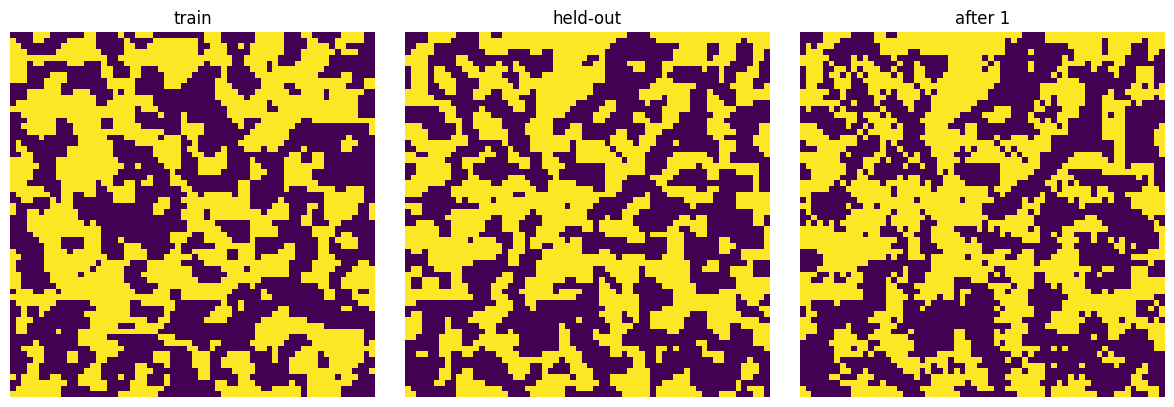

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from numpy.lib.stride_tricks import sliding_window_view

N_STEPS = 1                            
bits = 1 << np.arange(8)                

def keys_of(fields):                      # every 3x3 -> (neighbour-code, centre)
    w = sliding_window_view(fields, (3, 3), axis=(-2, -1)).reshape(-1, 9)
    return np.delete(w, 4, 1).dot(bits), w[:, 4]

# train on seeds 0..1000
fields = np.array([make_field(seed=s, scale=1.0) for s in range(1001)])
k, c = keys_of(fields)
counts = defaultdict(lambda: [0, 0])
for key, centre in zip(k, c):
    counts[key][int(centre)] += 1

p1 = np.array([counts[i][1] / sum(counts[i]) if i in counts else 0.5 for i in range(256)])

# held-out field (seed 1001) + run the rule N_STEPS times
test = make_field(seed=1001, scale=1.0)
rng = np.random.default_rng(0)
evolved = test.copy()
for _ in range(N_STEPS):
    key, _ = keys_of(evolved)
    evolved[1:-1, 1:-1] = (rng.random(key.shape) < p1[key]).reshape(62, 62)

# plot
for a, (img, t) in zip(plt.subplots(1, 3, figsize=(12, 4))[1],
                       [(fields[0], 'train'), (test, 'held-out'),
                        (evolved, f'after {N_STEPS}')]):
    a.imshow(img, origin='lower', cmap='viridis'); a.set_title(t); a.axis('off')
plt.tight_layout(); plt.show()

## random nosie

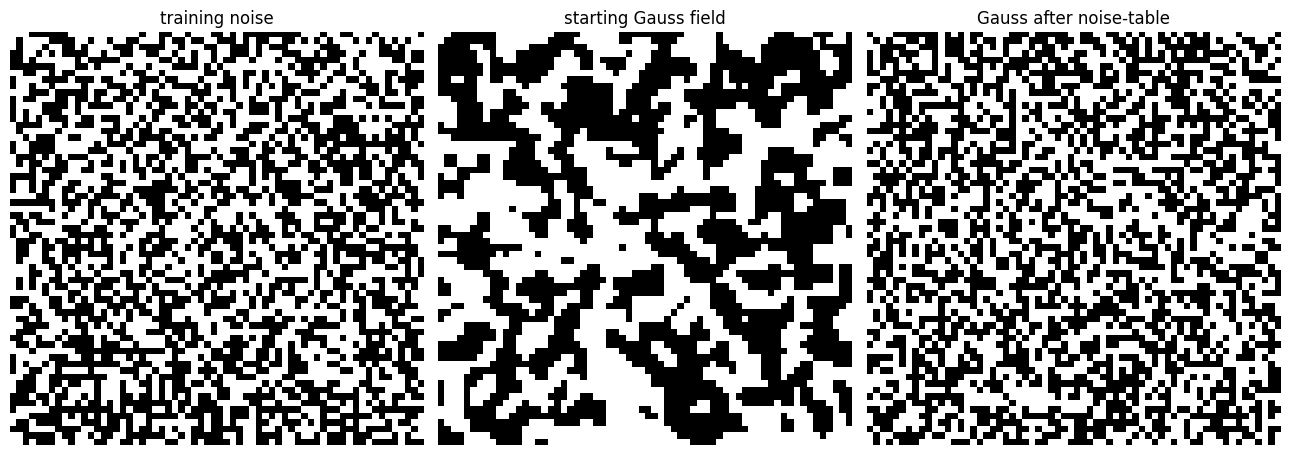

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from numpy.lib.stride_tricks import sliding_window_view

bits = 1 << np.arange(8)
def key_rigid(g):                                  
    return int(np.delete(g.flatten(), 4).dot(bits))

# RANDOM NOISE
rng = np.random.default_rng(0)
noise = np.array([rng.integers(0, 2, (64, 64)) for _ in range(1001)])

# probability table
w = sliding_window_view(noise, (3, 3), axis=(1, 2)).reshape(-1, 3, 3)
table = defaultdict(lambda: [0, 0])
for g in w:
    table[key_rigid(g)][int(g[1, 1])] += 1

def p1_lookup(g):
    n0, n1 = table.get(key_rigid(g), [0, 0])
    t = n0 + n1
    return n1 / t if t else 0.5

# GAUSS FIELD, apply the noise-table
def grow_field(start, sweeps=100, seed=0):
    rng = np.random.default_rng(seed)
    f = start.copy().astype(int)
    size = f.shape[0]
    for _ in range(sweeps):
        for r in range(size):
            for c in range(size):
                g = f[np.ix_([(r-1) % size, r, (r+1) % size],
                             [(c-1) % size, c, (c+1) % size])]
                f[r, c] = 1 if rng.random() < p1_lookup(g) else 0
    return f

gauss = make_field(seed=1001, scale=1.0)
new = grow_field(gauss, sweeps=1)

fig, ax = plt.subplots(1, 3, figsize=(13, 4.5))
ax[0].imshow(noise[0], cmap="gray"); ax[0].set_title("training noise")
ax[1].imshow(gauss,    cmap="gray"); ax[1].set_title("starting Gauss field")
ax[2].imshow(new,      cmap="gray"); ax[2].set_title("Gauss after noise-table")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()

# 1000 random images maped to a gauss field


In [39]:
import numpy as np
import gstools as gs
from scipy.stats import norm

# one shared Gaussian field 
x = y = range(64)
srf = gs.SRF(gs.Gaussian(dim=2, var=1, len_scale=[0.5, 0.5], angles=0))
srf((x, y), mesh_type='structured', seed=42)
gauss = srf.field
binary = (gauss > 0).astype(np.uint8)

# 1000 noisy versions of that structure
rng = np.random.default_rng(0)
images = rng.standard_normal((1000, 64, 64))

p_white = 0.30
threshold = norm.ppf(1 - p_white)

binary_images = (images > threshold).astype(np.uint8)


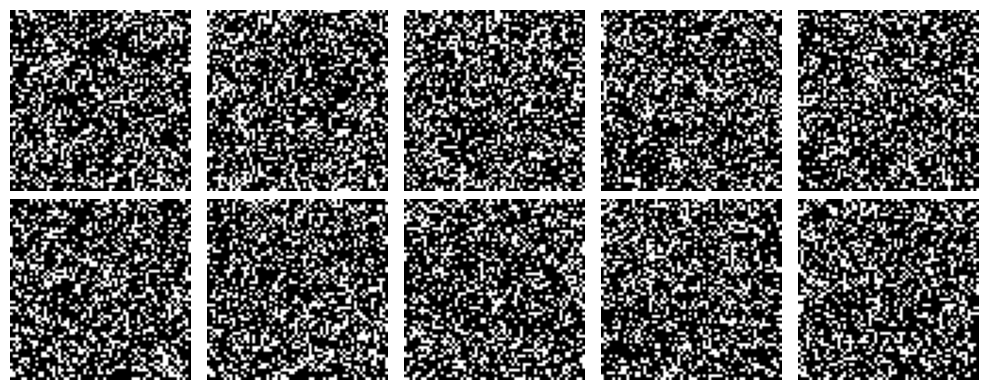

In [40]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for ax, img in zip(axes.ravel(), binary_images[:10]):
    ax.imshow(img, cmap="gray", vmin=0, vmax=1)
    ax.axis("off")

plt.tight_layout()
plt.show()

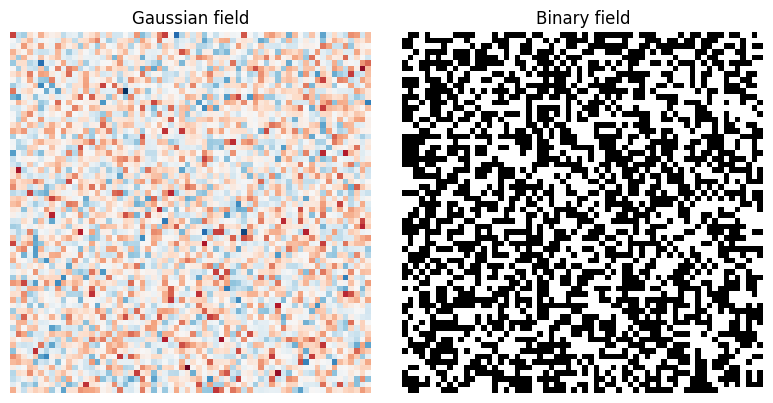

In [41]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(8, 4))

ax[0].imshow(gauss, cmap="RdBu_r")
ax[0].set_title("Gaussian field")
ax[0].axis("off")

ax[1].imshow(binary, cmap="gray", vmin=0, vmax=1)
ax[1].set_title("Binary field")
ax[1].axis("off")

plt.tight_layout()
plt.show()

In [48]:
# 1. Pick one of your noisy binary images (for example, the first one)
sample_noisy_binary = binary_images[0]

# 2. Compare it to the shared true binary field 
# ^ is the XOR 
difference_grid = binary ^ sample_noisy_binary


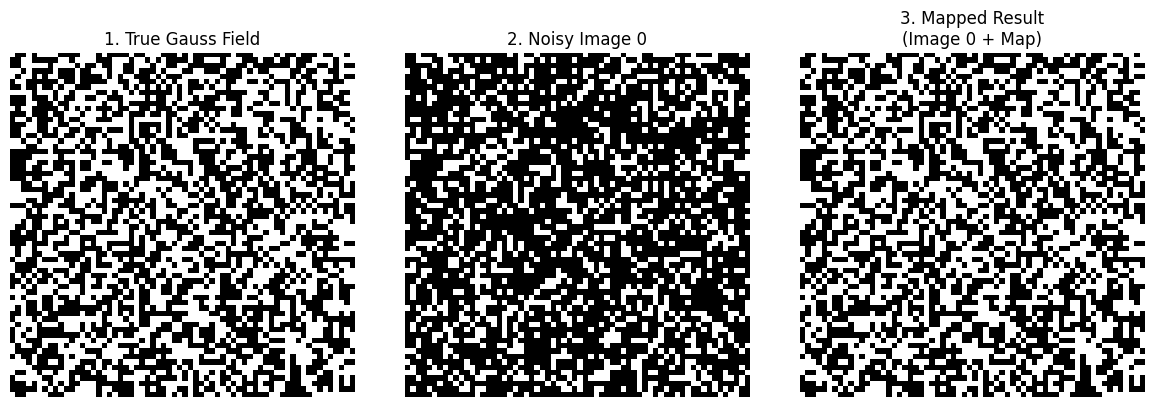

In [49]:
import numpy as np
import gstools as gs
from scipy.stats import norm
import matplotlib.pyplot as plt

# 1. Your original setup
x = y = range(64)
srf = gs.SRF(gs.Gaussian(dim=2, var=1, len_scale=[0.5, 0.5], angles=0))
srf((x, y), mesh_type='structured', seed=42)
gauss = srf.field
binary = (gauss > 0).astype(np.uint8)  # True Gauss field

# 1000 noisy versions
rng = np.random.default_rng(0)
images = rng.standard_normal((1000, 64, 64))
binary_images = (images > norm.ppf(1 - 0.30)).astype(np.uint8)

# 2. Map Image 0 to the True Gauss Field
image_0 = binary_images[0]
mapping_grid = binary ^ image_0  # The map (1 if change, 0 if not)

# Apply the map to Image 0 to reconstruct the Gauss field
mapped_result = image_0 ^ mapping_grid

# 3. Plot the 3 images (displays them directly, does not save)
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Plot 1: Original Gauss Field
axes[0].imshow(binary, cmap='gray')
axes[0].set_title("1. True Gauss Field")
axes[0].axis('off')

# Plot 2: Noisy Image 0
axes[1].imshow(image_0, cmap='gray')
axes[1].set_title("2. Noisy Image 0")
axes[1].axis('off')

# Plot 3: Mapped Result (Image 0 + Map)
axes[2].imshow(mapped_result, cmap='gray')
axes[2].set_title("3. Mapped Result\n(Image 0 + Map)")
axes[2].axis('off')

plt.tight_layout()
plt.show()